# Importeringar av biblotek och LLM

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
assert GROQ_API_KEY, "Saknar GROQ_API_KEY i .env"

In [21]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

if llm:
    print("LLM is initialized")

/Users/rikardsoderstrom/DataScience-uppgift/venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


LLM is initialized


In [45]:
conn = sqlite3.connect("ehandel_data_clean.db")


In [48]:
df = pd.read_sql("SELECT * FROM orderdata;", conn, parse_dates=["orderdatum", "leveransdatum", "recensionsdatum" ])


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            3150 non-null   str           
 1   orderrad_id         3150 non-null   str           
 2   orderdatum          3150 non-null   datetime64[us]
 3   leveransdatum       3150 non-null   datetime64[us]
 4   produkt_sku         3150 non-null   str           
 5   produktnamn         3150 non-null   str           
 6   kategori            3150 non-null   str           
 7   antal               2990 non-null   float64       
 8   pris_per_enhet      3150 non-null   float64       
 9   region              3150 non-null   str           
 10  kundtyp             3150 non-null   str           
 11  betalmetod          3150 non-null   str           
 12  kund_id             3150 non-null   str           
 13  leveransstatus      3037 non-null   str           
 14  rec

# System promptar till LLM

In [39]:
SYSTEM_PROMPT_FÖRSÄLJNING_KATEGORI = """
Du är en dataanalytiker för e-handel.

Mål:
Förklara möjliga orsaker till varför försäljningen per kategori är ojämnt fördelad,
med stöd i (1) kundbetyg och (2) kundrecensioner.

Regler:
- Utgå endast från den data som ges (försäljning, betyg, recensioner/sentiment).
- Gör rimliga hypoteser men var försiktig: använd "kan indikera", "kan bero på".
- Koppla slutsatser till konkreta datapunkter (t.ex. hög/låg snittbetyg, stor andel negativt sentiment, återkommande teman).
- Om data saknas eller är otydlig: säg det och föreslå vad som behövs för att bli säkrare.
- Svara på svenska i 8-12 meningar.
- Struktur:
  1) Kort sammanfattning av mönstret i försäljningen
  2) Koppling till betyg/kund recensioner per kategori
  3) 2-3 möjliga förklaringar
  4) 1-2 konkreta rekommendationer
"""


In [38]:
SYSTEM_PROMPT_FÖRSÄLJNING_PER_MÅNAD = """
Du är en dataanalytiker som analyserar tidsseriedata för e-handel.

Din uppgift är att tolka försäljning per månad och identifiera mönster över tid,
såsom toppar, dippar, trender och möjliga säsongseffekter.

Regler:
- Utgå endast från den försäljningsdata som ges.
- Dra inga säkra slutsatser om orsaker; använd formuleringar som
  "kan indikera", "kan bero på", "möjligen".
- Resonera i termer av säsong, efterfrågan och kundbeteende över tid.
- Jämför olika perioder (t.ex. början av året, sommarmånader, slutet av året).
- Skriv på svenska i 5 meningar.
"""


In [42]:
SYSTEM_PROMPT_ANTAL_ORDRAR_PER_MÅNAD = """
Du är en dataanalytiker som tolkar försäljningsdata över tid för en e-handelsplattform.

Din uppgift är att förklara varför en graf över antal ordrar per månad kan se ut som den gör,
baserat på mönster i tidsseriedata.

Regler:
- Utgå endast från den data som presenteras (antal ordrar per månad).
- Identifiera och beskriv trender, toppar och dippar.
- Resonera kring möjliga säsongseffekter och förändringar i kundbeteende över tid.
- Dra inga säkra slutsatser om orsaker; använd formuleringar som
  "kan indikera", "kan bero på", eller "möjligen".
- Anta att information om kampanjer, prissättning och externa faktorer saknas.
- Skriv på svenska i 5 sammanhängande meningar.
"""


# KPI 1. försäljning per månad

In [50]:
kpi_försäljning_per_månad = (
    df
    .groupby("månad_num")["rad_intakt"]
    .sum()
    .sort_index()
)

kpi_försäljning_per_månad

månad_num
1     2358642.0
2     1706435.0
3     1322594.0
4     1287872.0
5     1282418.0
6     1087638.0
7      823959.0
8     1056754.0
9     1122321.0
10    1711911.0
11    1824370.0
12    1294342.0
Name: rad_intakt, dtype: float64

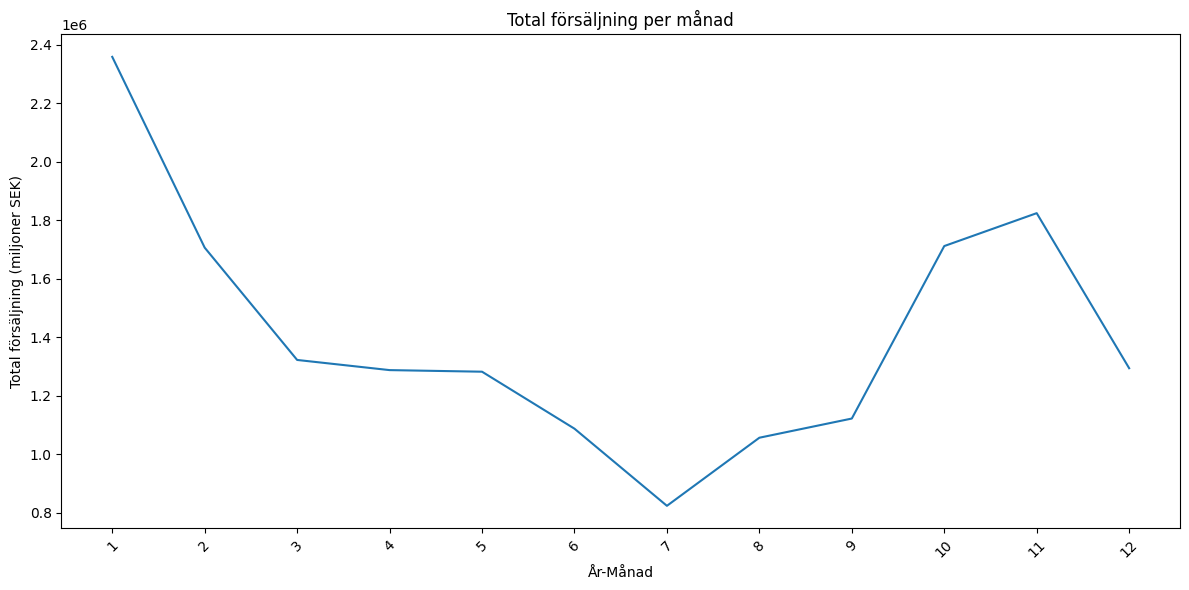

In [51]:
# 1) KPI per månad

plt.figure(figsize=(12,6))
plt.plot(kpi_försäljning_per_månad.index.astype(str),
         kpi_försäljning_per_månad.values)

plt.title("Total försäljning per månad")
plt.xlabel("År-Månad")
plt.ylabel("Total försäljning (miljoner SEK)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafen visar att försäljningen är som högst under januari månad. Därefter kan man se en succesiv nedgång fram till juli, där försäljningen når sin lägsta nivå. Därefter kan man se en återhämtning resterande av året. Mönstret kan visa att det varit starkare efterfrågan i början av året. Det kan också ha varit på grund av kampanjer eller säsongsefekter.

In [ ]:
summary = (
    kpi_försäljning_per_månad
    .round(0)
    .astype(int)
    .to_string()
)

response = llm.invoke([
    {
        "role": "system",
        "content": SYSTEM_PROMPT_FÖRSÄLJNING_PER_MÅNAD},
    {
        "role": "user",
        "content": f"""
Här är försäljningen per månad (i SEK):

{summary}       

Analysera utvecklingen över tid.
Identifiera tydliga toppar och dippar och beskriv hur försäljningen förändras
från början av året till sommaren och vidare mot slutet av perioden.
"""
    }
])

print(response.content)

Försäljningen startar året med en hög nivå på cirka 2,36 M SEK i januari och sjunker sedan kraftigt till en tydlig dip i juli på omkring 0,82 M SEK, vilket kan indikera en säsongsbunden minskning under sommarmånaderna. Efter den lägsta punkten i juli stiger försäljningen igen och når ett andra toppskede i oktober–november med 1,71 M–1,82 M SEK, vilket kan bero på högtider eller kampanjer inför årsskiftet. De tidiga månaderna (februari–maj) ligger relativt stabila men på en lägre nivå än januari, vilket kan tyda på en avtagande efterfrågan efter nyår. Hösten visar en återhämtning och en gradvis uppgång fram till november, men december sjunker åter till cirka 1,29 M SEK, vilket kan spegla en avmattning efter julhandeln. Sammantaget framträder ett mönster med en stark start, en sommar‑dip och en återhämtning mot slutet av året, vilket kan vara typiskt för säsongsvariationer i e‑handeln.


# KPI 2 försäljning per kategori

In [52]:
kpi_försäljning_kategori = (
    df
    .groupby("kategori")["rad_intakt"]
    .sum()
    .sort_values(ascending=False)
)

kpi_försäljning_kategori

kategori
Datorer        10857219.0
Bildskärmar     3281269.0
Tillbehör       1430052.0
Lagring          696561.0
Ljud             614155.0
Name: rad_intakt, dtype: float64

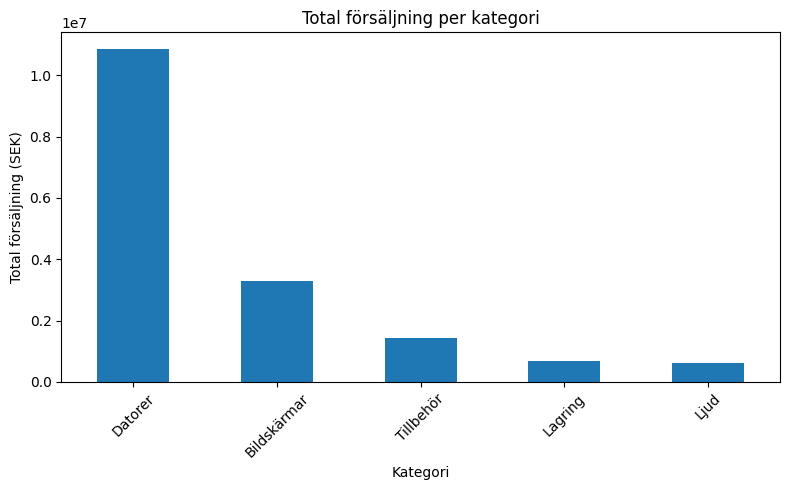

In [53]:
plt.figure(figsize=(8,5))
kpi_försäljning_kategori.plot(kind="bar")
plt.title("Total försäljning per kategori")
plt.xlabel("Kategori")
plt.ylabel("Total försäljning (SEK)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
summary = (
    kpi_försäljning_kategori
    .sort_values(ascending=False)
    .round(0)
    .astype(int)
    .to_string()
)

response = llm.invoke([
    {"role": "system", "content": SYSTEM_PROMPT_FÖRSÄLJNING_KATEGORI},
    {
        "role": "user",
        "content": f"""
Här är försäljning per produktkategori (i SEK):

{summary}

Analysera varför försäljningen kan vara ojämnt fördelad mellan kategorierna
och koppla resonemanget till kundbeteende, betyg och recensioner.
"""
    }
])

print(response.content)


**1) Sammanfattning av försäljningsmönstret**  
Försäljningen är kraftigt koncentrerad till Datorer (≈ 10,9 M SEK), medan de övriga kategorierna ligger betydligt lägre: Bildskärmar (≈ 3,3 M), Tillbehör (≈ 1,4 M), Lagring (≈ 0,7 M) och Ljud (≈ 0,6 M).  

**2) Koppling till betyg och kundrecensioner**  
Utan faktiska betyg‑ och recensionsdata kan vi bara spekulera, men en hög andel positiva betyg och återkommande positiva teman i recensionerna för Datorer skulle kunna förklara den starka försäljningen, medan lägre genomsnittsbetyg eller en hög andel negativt sentiment i Ljud‑ och Lagringskategorierna kan bidra till deras svagare resultat.  

**3) Möjliga förklaringar**  
- En hög kundnöjdhet för Datorer (t.ex. snittbetyg > 4,5) kan indikera att produkterna lever upp till förväntningarna och driver återköp samt rekommendationer.  
- Negativ feedback kring pris‑/värde‑förhållandet eller produktkvaliteten i Tillbehör och Ljud (t.ex. många kommentarer om kort livslängd eller bristande funkti

# KPI 3. Antal ordrar per månad

In [55]:

df["år_månad"] = df["orderdatum"].dt.to_period("M")


In [56]:
kpi_antal_ordrar_per_månad = (
    df.groupby("år_månad")["order_id"]
      .nunique()
      .sort_index()
)

kpi_antal_ordrar_per_månad

år_månad
2024-01    154
2024-02    147
2024-03    142
2024-04    140
2024-05    142
2024-06    111
2024-07    108
2024-08    107
2024-09    139
2024-10    154
2024-11    170
2024-12    170
2025-01    108
2025-02     98
2025-03      7
2025-04      6
2025-05     13
2025-06     10
2025-07      5
2025-08     10
2025-09      8
2025-10      8
2025-11     10
2025-12      6
Freq: M, Name: order_id, dtype: int64

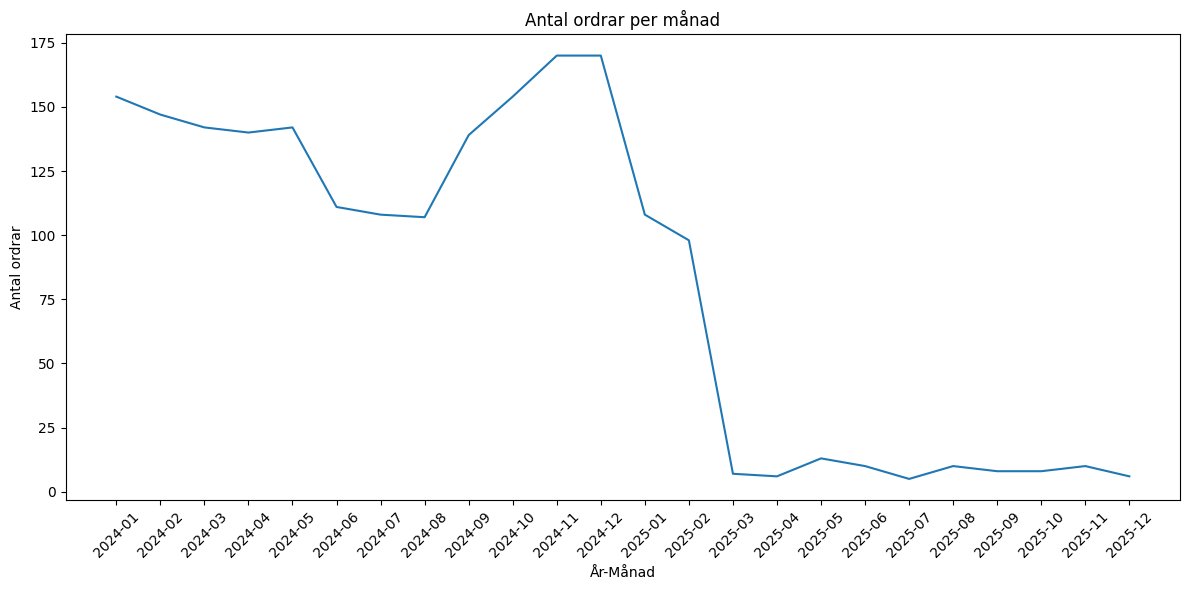

In [37]:
plt.figure(figsize=(12,6))
plt.plot(kpi_antal_ordrar_per_månad.index.astype(str),
         kpi_antal_ordrar_per_månad.values)

plt.title("Antal ordrar per månad")
plt.xlabel("År-Månad")
plt.ylabel("Antal ordrar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
summary = (
    kpi_försäljning_per_månad
    .round(0)
    .astype(int)
    .to_string()
)

response = llm.invoke([
    {"role": "system", "content": SYSTEM_PROMPT_ANTAL_ORDRAR_PER_MÅNAD},
    {"role": "user", "content": f"""
Här är försäljning per månad (SEK):

{summary}

Förklara varför utvecklingen kan se ut som den gör.
Fokusera särskilt på den tydliga toppen i början av året och dippen under juli månad.
"""
    }
])

print(response.content)


Den tydliga toppen i de första månaderna kan indikera en stark efterfrågan i början av året, kanske på grund av nyårsförsäljning eller att kunderna använder tidigare budgetmedel. Den gradvisa nedgången fram till juni tyder på en möjlig avtrappning när den initiala efterfrågan avtar och konsumenterna blir mer återhållsamma. Den markanta dippen i juli kan bero på sommarsezonens lägre köpkraft, då många är på semester och spenderar mindre på e‑handel. Den efterföljande återhämtningen i augusti‑november kan möjligen spegla en återgång till normal köpbeteende samt införandet av högtidsrelaterade inköp inför hösten. Överlag visar serien en säsongsbetonad cykel med högre aktivitet i början av året och en återkommande sommarvila, vilket är typiskt för många detaljhandelssegment.
